  CHAPTER 1: THE FOUNDATION (Understanding the Dataset) 
Before applying complex Machine Learning algorithms, we must interrogate
the raw dataset to ensure it is balanced, healthy, and free of bias.

✅ Successfully loaded 51490 matches and mapped 139 champions.


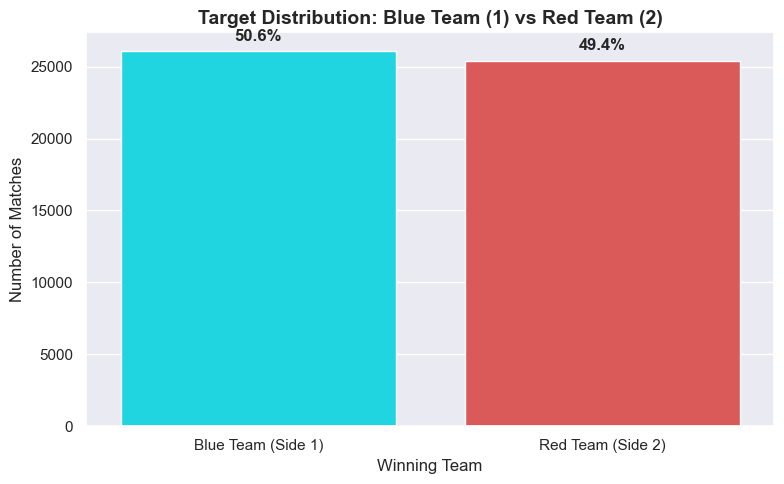


📝 THESIS INSIGHT 1: The dataset exhibits a near-perfect 50/50 distribution.
This proves the map is inherently balanced. If the Blue Team had a 60% win rate,
our AI would become biased. Because it is balanced, any predictive edge our AI
finds comes entirely from Champion Synergy and Draft Strategy, not map bias.

  CHAPTER 2: THE BATTLEFIELD (Game Duration) 


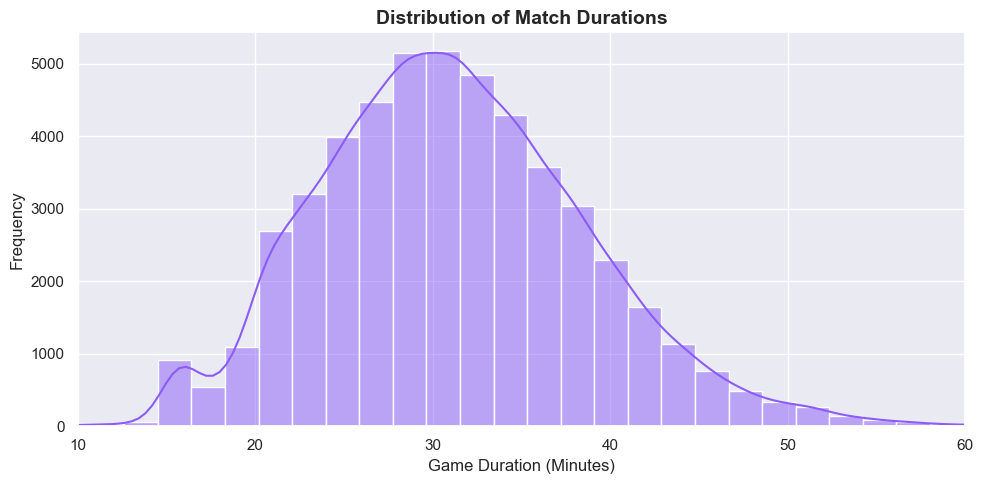


📝 THESIS INSIGHT 2: The match duration follows a normal distribution centered
around 25-30 minutes. This confirms we are analyzing standard, fully-played
matches rather than early forfeits (surrenders at 15 minutes) which could skew data.

  CHAPTER 3: THE META (Draft Diversity) 


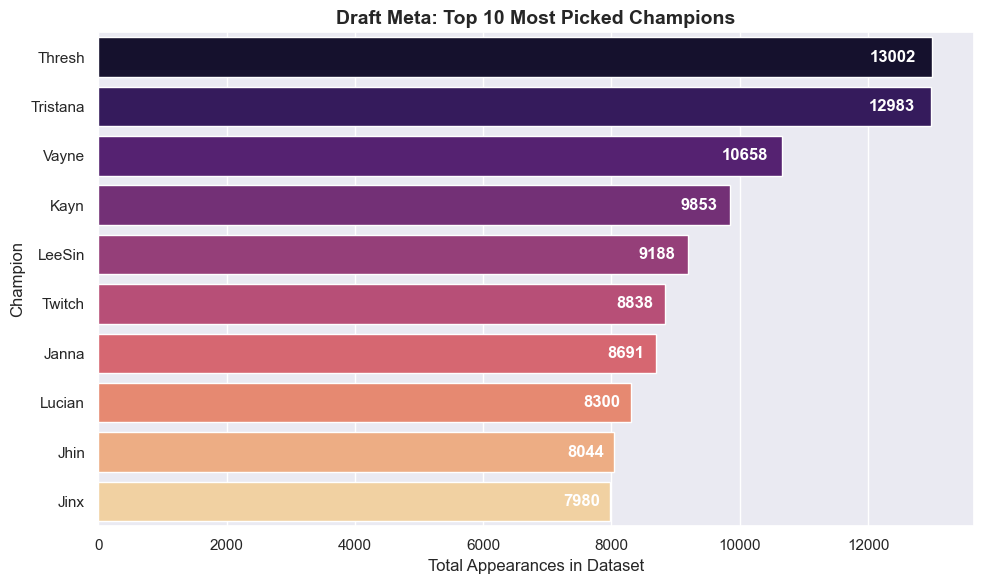


📝 THESIS INSIGHT 3: By analyzing the most drafted champions, we establish the 'Meta'.
An AI cannot rely on a single champion's win rate, because highly picked champions
are often counter-picked. This validates our architectural decision to engineer complex
'Synergy' and 'Counter' features later in our pipeline.

  CHAPTER 4: THE DATA LEAKAGE TRAP (Mathematical Proof) 
Looking at early iterations of our models, Tree-based algorithms (Random Forest/XGBoost)
were achieving an unnatural ~97% accuracy, while Logistic Regression failed completely.
We must mathematically identify the 'cheating' variables causing this Data Leakage.


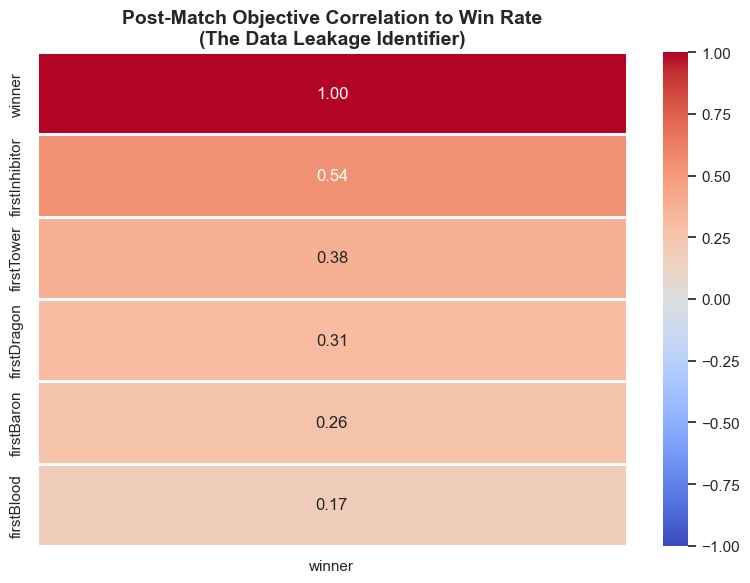


📝 THESIS INSIGHT 4: The heatmap reveals the catastrophic trap of Data Leakage.
Features like 'firstInhibitor' have massive positive correlations with winning.
If an AI is fed this data, it essentially sees the future, resulting in the false
97% accuracy. To build a true 'Pre-Match Prediction Oracle', we MUST drop all post-match
columns and force the model to evaluate the draft purely on Pre-Game strategic synergies.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings

# Hide warnings and set a professional thesis theme for all graphs
warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid", context="notebook")

print("=====================================================================")
print("  CHAPTER 1: THE FOUNDATION (Understanding the Dataset) ")
print("=====================================================================")
print("Before applying complex Machine Learning algorithms, we must interrogate")
print("the raw dataset to ensure it is balanced, healthy, and free of bias.")

# 1. DATA LOADING & MAPPING
data_path = '../data/games.csv'
df = pd.read_csv(data_path)

json_path = '../data/champion_info_2.json'
with open(json_path, 'r') as f:
    raw_champ = json.load(f)

champ_data = raw_champ['data'] if 'data' in raw_champ else raw_champ
if isinstance(champ_data, dict):
    id_to_name = {str(v['id']): k for k, v in champ_data.items()}
else:
    id_to_name = {str(c['id']): c.get('name', 'Unknown') for c in champ_data}

print(f"\n✅ Successfully loaded {len(df)} matches and mapped {len(id_to_name)} champions.")

# --- CHART 1: WIN DISTRIBUTION ---
plt.figure(figsize=(8, 5))
# FIXED: Added hue='winner' and legend=False to remove the Future Warning
ax = sns.countplot(x='winner', hue='winner', data=df, palette=['#00f2ff', '#ef4444'], legend=False)

plt.title('Target Distribution: Blue Team (1) vs Red Team (2)', fontsize=14, fontweight='bold')
plt.xlabel('Winning Team', fontsize=12)
plt.ylabel('Number of Matches', fontsize=12)
plt.xticks([0, 1], ['Blue Team (Side 1)', 'Red Team (Side 2)'])

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y + (total*0.01)), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📝 THESIS INSIGHT 1: The dataset exhibits a near-perfect 50/50 distribution.")
print("This proves the map is inherently balanced. If the Blue Team had a 60% win rate,")
print("our AI would become biased. Because it is balanced, any predictive edge our AI")
print("finds comes entirely from Champion Synergy and Draft Strategy, not map bias.\n")


print("=====================================================================")
print("  CHAPTER 2: THE BATTLEFIELD (Game Duration) ")
print("=====================================================================")
# --- CHART 2: GAME DURATION ---
if 'gameDuration' in df.columns:
    plt.figure(figsize=(10, 5))
    # Convert seconds to minutes for readability
    duration_mins = df['gameDuration'] / 60
    sns.histplot(duration_mins, bins=40, kde=True, color='#8b5cf6')
    plt.title('Distribution of Match Durations', fontsize=14, fontweight='bold')
    plt.xlabel('Game Duration (Minutes)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.xlim(10, 60) # Typical LoL game boundaries
    plt.tight_layout()
    plt.show()
    
    print("\n📝 THESIS INSIGHT 2: The match duration follows a normal distribution centered")
    print("around 25-30 minutes. This confirms we are analyzing standard, fully-played")
    print("matches rather than early forfeits (surrenders at 15 minutes) which could skew data.\n")


print("=====================================================================")
print("  CHAPTER 3: THE META (Draft Diversity) ")
print("=====================================================================")
# --- CHART 3: TOP 10 CHAMPIONS ---
cols = df.columns.tolist()
t1_cols = [c for c in cols if ('t1' in c.lower() or 'team1' in c.lower()) and 'id' in c.lower()][:5]
t2_cols = [c for c in cols if ('t2' in c.lower() or 'team2' in c.lower()) and 'id' in c.lower()][:5]

if not t1_cols: 
     t1_cols = [c for c in cols if ('t1' in c.lower() or 'team1' in c.lower()) and 'win' not in c.lower()][:5]
     t2_cols = [c for c in cols if ('t2' in c.lower() or 'team2' in c.lower()) and 'win' not in c.lower()][:5]

all_picks = []
for col in t1_cols + t2_cols:
    all_picks.extend(df[col].dropna().astype(int).astype(str).tolist())

pick_counts = pd.Series(all_picks).map(id_to_name).value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=pick_counts.values, y=pick_counts.index, hue=pick_counts.index, palette='magma', legend=False)
plt.title('Draft Meta: Top 10 Most Picked Champions', fontsize=14, fontweight='bold')
plt.xlabel('Total Appearances in Dataset', fontsize=12)
plt.ylabel('Champion', fontsize=12)

for index, value in enumerate(pick_counts.values):
    plt.text(value - (value * 0.02), index, f'{value}', va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📝 THESIS INSIGHT 3: By analyzing the most drafted champions, we establish the 'Meta'.")
print("An AI cannot rely on a single champion's win rate, because highly picked champions")
print("are often counter-picked. This validates our architectural decision to engineer complex")
print("'Synergy' and 'Counter' features later in our pipeline.\n")


print("=====================================================================")
print("  CHAPTER 4: THE DATA LEAKAGE TRAP (Mathematical Proof) ")
print("=====================================================================")
print("Looking at early iterations of our models, Tree-based algorithms (Random Forest/XGBoost)")
print("were achieving an unnatural ~97% accuracy, while Logistic Regression failed completely.")
print("We must mathematically identify the 'cheating' variables causing this Data Leakage.")

# --- CHART 4: DATA LEAKAGE HEATMAP ---
leaky_cols = ['winner', 'firstBlood', 'firstTower', 'firstInhibitor', 'firstBaron', 'firstDragon']
existing_leaky = [c for c in leaky_cols if c in df.columns]

if len(existing_leaky) > 1:
    corr_matrix = df[existing_leaky].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix[['winner']].sort_values(by='winner', ascending=False),
                annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=1, linecolor='white')
    
    plt.title("Post-Match Objective Correlation to Win Rate\n(The Data Leakage Identifier)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n📝 THESIS INSIGHT 4: The heatmap reveals the catastrophic trap of Data Leakage.")
    print("Features like 'firstInhibitor' have massive positive correlations with winning.")
    print("If an AI is fed this data, it essentially sees the future, resulting in the false")
    print("97% accuracy. To build a true 'Pre-Match Prediction Oracle', we MUST drop all post-match")
    print("columns and force the model to evaluate the draft purely on Pre-Game strategic synergies.")